In [1]:
# ==============================================================================
# CELL 1: SETUP AND IMPORTS
# ==============================================================================

# Standard Library
import os
import shutil
import random
import itertools
import time

# Numerical & Data Handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# PyTorch & Deep Learning
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import CosineAnnealingLR
import timm

# Scikit-Learn (Machine Learning)
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)
from sklearn.model_selection import train_test_split

# Extra ML/Stats Tools
from scipy.special import softmax
from sklearn.manifold import TSNE

# Progress Bar
from tqdm import tqdm

# Kaggle
import kagglehub

# Image handling
from PIL import Image
from urllib.request import urlopen
from copy import deepcopy


print("All libraries imported successfully.")


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

All libraries imported successfully.


In [2]:
# ==============================================================================
# CELL 2: DOWNLOAD AND PREPARE DATASET
# ==============================================================================
# --- Download from Kaggle ---
path = kagglehub.dataset_download("mdriyadhossain/ai-medleafx")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/


In [3]:
dataset_path = "/kaggle/input/"
print("Verified path to dataset files:", dataset_path)

# Assuming the structure is dataset_path -> 'Resized Image' -> Plant Type -> Disease/Health Status -> Images
resized_image_base_path = os.path.join(dataset_path, 'Resized Image')

all_class_dirs = []
class_counts = {}

print("\nExploring dataset structure and counting images:")

try:
    # List plant type directories within 'Resized Image'
    plant_type_dirs = [d for d in os.listdir(resized_image_base_path) if os.path.isdir(os.path.join(resized_image_base_path, d))]
    print(f"\nFound {len(plant_type_dirs)} plant types:", plant_type_dirs)

    if not plant_type_dirs:
        print("No plant type directories found within 'Resized Image'. Cannot proceed with expected structure.")
    else:
        # Iterate through each plant type directory
        for plant_type_dir in plant_type_dirs:
            plant_type_path = os.path.join(resized_image_base_path, plant_type_dir)

            # List disease/health status directories within each plant type
            status_dirs = [d for d in os.listdir(plant_type_path) if os.path.isdir(os.path.join(plant_type_path, d))]
            print(f"\nExploring '{plant_type_dir}': Found {len(status_dirs)} status categories:", status_dirs)

            if not status_dirs:
                print(f"No status directories found within '{plant_type_dir}'.")
            else:
                # Iterate through each status directory (these are the actual classes)
                for status_dir in status_dirs:
                    class_name = f"{plant_type_dir}_{status_dir}" # Combine plant type and status for a unique class name
                    class_path = os.path.join(plant_type_path, status_dir)
                    all_class_dirs.append(class_name)

                    # Count image files in the class directory
                    image_files_in_class = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg','.JPG'))]
                    class_counts[class_name] = len(image_files_in_class)
                    print(f"- {class_name}: {class_counts[class_name]} images")

        # Determine the total number of classes
        num_classes = len(all_class_dirs)
        print(f"\nTotal number of classes: {num_classes}")

        # Display class distribution summary
        print("\nClass distribution:")
        for class_name, count in class_counts.items():
            print(f"- {class_name}: {count}")

        # Calculate total number of images
        total_images = sum(class_counts.values())
        print(f"\nTotal number of images: {total_images}")

except FileNotFoundError:
    print(f"Error: The directory '{resized_image_base_path}' was not found.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")


print("\nDataset exploration and counting complete.")

Verified path to dataset files: /kaggle/input/

Exploring dataset structure and counting images:

Found 4 plant types: ['Sojina', 'Neem', 'Camphor', 'HariTaki']

Exploring 'Sojina': Found 3 status categories: ['Yellow Leaf', 'Healthy Leaf', 'Bacterial Spot']
- Sojina_Yellow Leaf: 814 images
- Sojina_Healthy Leaf: 860 images
- Sojina_Bacterial Spot: 804 images

Exploring 'Neem': Found 4 status categories: ['Powdery Mildew', 'Yellow Leaf', 'Healthy Leaf', 'Shot Hole Leaf']
- Neem_Powdery Mildew: 854 images
- Neem_Yellow Leaf: 854 images
- Neem_Healthy Leaf: 1021 images
- Neem_Shot Hole Leaf: 834 images

Exploring 'Camphor': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- Camphor_Healthy Leaf: 800 images
- Camphor_Shot Hole: 795 images
- Camphor_Bacterial Spot: 801 images

Exploring 'HariTaki': Found 3 status categories: ['Healthy Leaf', 'Shot Hole', 'Bacterial Spot']
- HariTaki_Healthy Leaf: 816 images
- HariTaki_Shot Hole: 802 images
- HariTaki_Bacterial Spo

In [4]:
# ==============================================================================
# CELL 3: DATA SPLITTING
# ==============================================================================

# Define paths
original_base_dir = os.path.join(dataset_path, 'Resized Image')
new_base_dir = '/content/data'

# Collect image paths and labels
data = []
for plant in os.listdir(original_base_dir):
    for status in os.listdir(os.path.join(original_base_dir, plant)):
        label = f"{plant}_{status}"
        path = os.path.join(original_base_dir, plant, status)
        for fname in os.listdir(path):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png','.JPG')):
                data.append({'path': os.path.join(path, fname), 'label': label})

df = pd.DataFrame(data)

# Split dataset: 80% train, 10% val, 10% test
train_val, test = train_test_split(df, test_size=0.1, stratify=df['label'], random_state=42)
train, val = train_test_split(train_val, test_size=0.1, stratify=train_val['label'], random_state=42)
# Output summary
total = len(df)
print(f"\n Dataset Split Summary:")
print(f"- Total images: {total}")
print(f"- Training set : {len(train):5d} images ({len(train)/total:.1%})")
print(f"- Validation set: {len(val):5d} images ({len(val)/total:.1%})")
print(f"- Test set     : {len(test):5d} images ({len(test)/total:.1%})\n")

# Copy files
for split_df, split in zip([train, val, test], ['train', 'val', 'test']):
    print(f" Copying {split} files...")
    for _, row in split_df.iterrows():
        dst_dir = os.path.join(new_base_dir, split, row['label'])
        os.makedirs(dst_dir, exist_ok=True)
        shutil.copy(row['path'], os.path.join(dst_dir, os.path.basename(row['path'])))
    print(f" {split.capitalize()} files copied: {len(split_df)}")

print("\n All files have been split and copied successfully.")


 Dataset Split Summary:
- Total images: 10858
- Training set :  8794 images (81.0%)
- Validation set:   978 images (9.0%)
- Test set     :  1086 images (10.0%)

 Copying train files...
 Train files copied: 8794
 Copying val files...
 Val files copied: 978
 Copying test files...
 Test files copied: 1086

 All files have been split and copied successfully.


In [5]:
seed = 42
torch.manual_seed(seed)
torch.cuda.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [6]:
# ============================================================================
# DATA LOADING
# ============================================================================
from torch.utils.data import Dataset
from PIL import Image

class ImageDataset(Dataset):
    """Custom dataset for image classification"""
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            image = self.transform(image)

        return image, label


def get_dinov2_transforms(is_training=False, img_size=224):
    """Get DINOv2-specific transforms"""
    if is_training:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(15),
            transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
        ])

In [7]:
class TwoViewTransform:
    """Create two augmented views of the same image for contrastive learning"""
    def __init__(self, base_transform):
        self.base_transform = base_transform

    def __call__(self, x):
        view1 = self.base_transform(x)
        view2 = self.base_transform(x)
        return view1, view2


# Augmentation pipeline for histology images
def get_augmentation_pipeline(img_size=224):
    """
    Strong augmentation pipeline for histology images
    """
    augmentation = transforms.Compose([
        transforms.RandomResizedCrop(img_size, scale=(0.2, 1.0)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(),
        transforms.RandomApply([
            transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)
        ], p=0.8),
        transforms.RandomGrayscale(p=0.2),
        transforms.RandomApply([transforms.GaussianBlur(kernel_size=23)], p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                           std=[0.229, 0.224, 0.225])
    ])

    return TwoViewTransform(augmentation)


In [8]:
# ## 3. MoCo v3 Model Architecture

# ```python
class MoCov3(nn.Module):
    """
    MoCo v3 implementation for self-supervised learning on histology images.
    """
    def __init__(
        self,
        base_encoder="vit_small_patch16_224",
        dim=256,
        mlp_dim=4096,
        T=1.0,
        momentum=0.99,
        num_heads=12,
    ):
        """
        Args:
            base_encoder: Base encoder architecture (ViT-Small by default)
            dim: Feature dimension for contrastive learning
            mlp_dim: Hidden dimension of projection MLP
            T: Temperature parameter for contrastive loss
            momentum: Momentum coefficient for updating momentum encoder
            num_heads: Number of attention heads for ViT
        """
        super(MoCov3, self).__init__()

        self.T = T
        self.momentum = momentum

        # Online encoder (query encoder)
        self.encoder_q = timm.create_model(
            model_name=base_encoder,
            pretrained=False,
            num_classes=0,  # Remove classification head
            num_heads=num_heads,
        )

        # Get feature dimension from encoder
        with torch.no_grad():
            dummy_input = torch.randn(1, 3, 224, 224)
            feat_dim = self.encoder_q(dummy_input).shape[1]

        # Projection head for online encoder
        self.projection_q = nn.Sequential(
            nn.Linear(feat_dim, mlp_dim),
            nn.BatchNorm1d(mlp_dim),
            nn.ReLU(inplace=True),
            nn.Linear(mlp_dim, mlp_dim),
            nn.BatchNorm1d(mlp_dim),
            nn.ReLU(inplace=True),
            nn.Linear(mlp_dim, dim),
            nn.BatchNorm1d(dim, affine=False)  # Output layer
        )

        # Prediction head (only for online encoder)
        self.predictor = nn.Sequential(
            nn.Linear(dim, mlp_dim),
            nn.BatchNorm1d(mlp_dim),
            nn.ReLU(inplace=True),
            nn.Linear(mlp_dim, dim)
        )

        # Momentum encoder (key encoder)
        self.encoder_k = deepcopy(self.encoder_q)
        self.projection_k = deepcopy(self.projection_q)

        # Freeze momentum encoder - no gradients
        for param_q, param_k in zip(
            self.encoder_q.parameters(), self.encoder_k.parameters()
        ):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False

        for param_q, param_k in zip(
            self.projection_q.parameters(), self.projection_k.parameters()
        ):
            param_k.data.copy_(param_q.data)
            param_k.requires_grad = False

    @torch.no_grad()
    def _update_momentum_encoder(self):
        """
        Momentum update of the momentum encoder using exponential moving average
        """
        for param_q, param_k in zip(
            self.encoder_q.parameters(), self.encoder_k.parameters()
        ):
            param_k.data = param_k.data * self.momentum + param_q.data * (1.0 - self.momentum)

        for param_q, param_k in zip(
            self.projection_q.parameters(), self.projection_k.parameters()
        ):
            param_k.data = param_k.data * self.momentum + param_q.data * (1.0 - self.momentum)

    def contrastive_loss(self, q, k):
        """
        Contrastive loss using InfoNCE
        Args:
            q: Query features (N, dim)
            k: Key features (N, dim)
        """
        # Normalize
        q = nn.functional.normalize(q, dim=1)
        k = nn.functional.normalize(k, dim=1)

        # Positive logits: Nx1
        l_pos = torch.einsum('nc,nc->n', [q, k]).unsqueeze(-1)

        # Negative logits: NxN
        l_neg = torch.einsum('nc,mc->nm', [q, k])

        # Logits: Nx(1+N)
        logits = torch.cat([l_pos, l_neg], dim=1)

        # Apply temperature
        logits /= self.T

        # Labels: positive key indicators
        labels = torch.zeros(logits.shape[0], dtype=torch.long, device=q.device)

        # Contrastive loss
        loss = nn.CrossEntropyLoss()(logits, labels)

        return loss

    def forward(self, x1, x2):
        """
        Forward pass for training
        Args:
            x1: First augmented view (N, 3, 224, 224)
            x2: Second augmented view (N, 3, 224, 224)
        Returns:
            loss: Contrastive loss
        """
        # Compute query features
        feat_q1 = self.encoder_q(x1)
        z_q1 = self.projection_q(feat_q1)
        p_q1 = self.predictor(z_q1)

        feat_q2 = self.encoder_q(x2)
        z_q2 = self.projection_q(feat_q2)
        p_q2 = self.predictor(z_q2)

        # Compute key features (no gradient)
        with torch.no_grad():
            # Update momentum encoder
            self._update_momentum_encoder()

            feat_k1 = self.encoder_k(x1)
            z_k1 = self.projection_k(feat_k1)

            feat_k2 = self.encoder_k(x2)
            z_k2 = self.projection_k(feat_k2)

        # Compute symmetrized loss
        loss = self.contrastive_loss(p_q1, z_k2) + self.contrastive_loss(p_q2, z_k1)

        return loss

    def extract_features(self, x):
        """
        Extract features for inference
        Args:
            x: Input images (N, 3, 224, 224)
        Returns:
            features: Extracted features (N, feat_dim)
        """
        self.eval()
        with torch.no_grad():
            features = self.encoder_q(x)
        return features

In [9]:
# ## 4. Training Loop

# ```python
def train_one_epoch(model, dataloader, optimizer, device, epoch):
    """
    Train for one epoch
    """
    model.train()
    total_loss = 0

    for batch_idx, (view1, view2) in enumerate(dataloader):
        view1 = view1.to(device)
        view2 = view2.to(device)

        # Forward pass
        loss = model(view1, view2)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"Epoch [{epoch}] Batch [{batch_idx}/{len(dataloader)}] "
                  f"Loss: {loss.item():.4f}")

    avg_loss = total_loss / len(dataloader)
    return avg_loss


def train_mocov3(model, dataloader, num_epochs=100, lr=1e-3, device='cuda'):
    """
    Full training loop for MoCo v3
    """
    model = model.to(device)

    # Optimizer (LARS or AdamW typically used)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.1)

    # Learning rate scheduler (cosine decay)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

    for epoch in range(num_epochs):
        avg_loss = train_one_epoch(model, dataloader, optimizer, device, epoch)
        scheduler.step()

        print(f"\nEpoch [{epoch+1}/{num_epochs}] "
              f"Average Loss: {avg_loss:.4f} "
              f"LR: {scheduler.get_last_lr()[0]:.6f}\n")

        # Save checkpoint
        if (epoch + 1) % 10 == 0:
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss': avg_loss,
            }, f'mocov3_checkpoint_epoch_{epoch+1}.pth')

In [10]:
# ============================================================================
# DEFINE GLOBAL VARIABLES FOR DATA LOADING AND MODEL
# ============================================================================

# Get the actual number of classes from the dataset exploration
NUM_CLASSES = len(all_class_dirs)
print(f"Global NUM_CLASSES set to: {NUM_CLASSES}")

# Create a mapping from class name string to integer label
class_to_idx = {class_name: i for i, class_name in enumerate(sorted(all_class_dirs))}
idx_to_class = {i: class_name for class_name, i in class_to_idx.items()}
print(f"Class mapping created: {class_to_idx}")

# Define device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")


# Define the DINOv2 model creation function
class DINOv2Classifier(nn.Module):
    def __init__(self, num_classes, freeze_backbone=True, model_variant='base'):
        super().__init__()
        if model_variant == 'base':
            # Using a fine-tuned DINOv2 ViT-Base model from torch.hub
            self.feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
            self.feature_dim = self.feature_extractor.embed_dim # Typically 768 for ViT-Base
        elif model_variant == 'small':
            # Using a fine-tuned DINOv2 ViT-Small model from torch.hub
            self.feature_extractor = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14')
            self.feature_dim = self.feature_extractor.embed_dim # Typically 384 for ViT-Small
        else:
            raise ValueError(f"Unsupported model_variant: {model_variant}. Choose 'base' or 'small'.")

        if freeze_backbone:
            for param in self.feature_extractor.parameters():
                param.requires_grad = False

        # Add a new classification head
        self.classifier = nn.Sequential(
            nn.Linear(self.feature_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        features = self.feature_extractor(x)
        logits = self.classifier(features)
        return logits

    def get_features(self, x):
        # Method to get backbone features without passing through the classifier
        return self.feature_extractor(x)

# Function to create the model (wrapper for DINOv2Classifier)
def create_model(num_classes, freeze_backbone=True, model_variant='base'):
    return DINOv2Classifier(num_classes, freeze_backbone, model_variant)


# Instantiate the DINOv2 model globally
# Using 'base' variant and freezing backbone for feature extraction
m_model = create_model(
    num_classes=NUM_CLASSES,
    freeze_backbone=True,
    model_variant='base'
)
m_model = m_model.to(DEVICE)
print("Global DINOv2 model instantiated and moved to device.")

BATCH_SIZE = 32
IMG_SIZE = 518 # DINOv2 default input size


Global NUM_CLASSES set to: 13
Class mapping created: {'Camphor_Bacterial Spot': 0, 'Camphor_Healthy Leaf': 1, 'Camphor_Shot Hole': 2, 'HariTaki_Bacterial Spot': 3, 'HariTaki_Healthy Leaf': 4, 'HariTaki_Shot Hole': 5, 'Neem_Healthy Leaf': 6, 'Neem_Powdery Mildew': 7, 'Neem_Shot Hole Leaf': 8, 'Neem_Yellow Leaf': 9, 'Sojina_Bacterial Spot': 10, 'Sojina_Healthy Leaf': 11, 'Sojina_Yellow Leaf': 12}
Using device: cuda


Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")
Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth
100%|██████████| 330M/330M [00:04<00:00, 72.4MB/s]


Global DINOv2 model instantiated and moved to device.


In [11]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [12]:
# Create model
model = MoCov3(
    base_encoder="vit_small_patch16_224",
    dim=256,
    mlp_dim=4096,
    T=1.0,
    momentum=0.99,
    num_heads=12
)

print(f"Model created with {sum(p.numel() for p in model.parameters())/1e6:.2f}M parameters")


Model created with 84.29M parameters


In [13]:
# Example: Load a single histology image
img = Image.open(
    urlopen(
        "https://github.com/owkin/HistoSSLscaling/raw/main/assets/example.tif"
    )
)

# Get augmentation transforms
transform = get_augmentation_pipeline(img_size=224)

# Create two views
view1, view2 = transform(img)
print(f"View 1 shape: {view1.shape}")
print(f"View 2 shape: {view2.shape}")

# Add batch dimension and test forward pass
# To satisfy BatchNorm1d requirements, we need a batch size > 1 for training mode.
# We'll duplicate the single view to create a batch of size 2 for this example.
view1_batch = torch.cat([view1.unsqueeze(0), view1.unsqueeze(0)], dim=0).to(device)
view2_batch = torch.cat([view2.unsqueeze(0), view2.unsqueeze(0)], dim=0).to(device)

model = model.to(device)
model.train() # Ensure model is in training mode for the loss calculation (MoCov3's forward implies training)
loss = model(view1_batch, view2_batch)
print(f"Contrastive Loss: {loss.item():.4f}")

# Extract features
# Set model to evaluation mode for feature extraction, which handles BatchNorm for batch size 1.
model.eval()
features = model.extract_features(view1.unsqueeze(0).to(device))
print(f"Extracted feature shape: {features.shape}")
# ```

View 1 shape: torch.Size([3, 224, 224])
View 2 shape: torch.Size([3, 224, 224])
Contrastive Loss: 2.1972
Extracted feature shape: torch.Size([1, 384])


In [14]:
# ## 6. Loading Pretrained Weights

# ```python
# To load the pretrained TransPath weights from your example:
pretrained_encoder = timm.create_model(
    model_name="hf-hub:1aurent/vit_small_patch16_224.transpath_mocov3",
    pretrained=True,
    num_heads=12,
    num_classes=0
)

# Replace the online encoder with pretrained weights
model.encoder_q = pretrained_encoder.to(device) # <--- Added .to(device) here
print("Loaded pretrained TransPath weights!")

# Now you can fine-tune or extract features
test_transform = timm.data.create_transform(
    **timm.data.resolve_model_data_config(pretrained_encoder),
    is_training=False
)

img_transformed = test_transform(img).unsqueeze(0).to(device)
features = model.extract_features(img_transformed)
print(f"Features from pretrained model: {features.shape}")

config.json:   0%|          | 0.00/568 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/86.7M [00:00<?, ?B/s]

Loaded pretrained TransPath weights!
Features from pretrained model: torch.Size([1, 384])


Train DataLoader created with 8794 images.
Validation DataLoader created with 978 images.
Test DataLoader created with 1086 images.
Using current DINOv2Classifier model weights.

Extracting Classification Head Output (Logits, 13-dim)


Extracting embeddings: 100%|██████████| 34/34 [00:56<00:00,  1.67s/it]


Embeddings shape: (1086, 13)
Labels shape: (1086,)

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1086 samples in 0.003s...
[t-SNE] Computed neighbors for 1086 samples in 0.053s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1086
[t-SNE] Computed conditional probabilities for sample 1086 / 1086
[t-SNE] Mean sigma: 0.239197
[t-SNE] KL divergence after 250 iterations with early exaggeration: 63.886879
[t-SNE] KL divergence after 1000 iterations: 1.158666
Saved visualization to tsne_logits_test.png


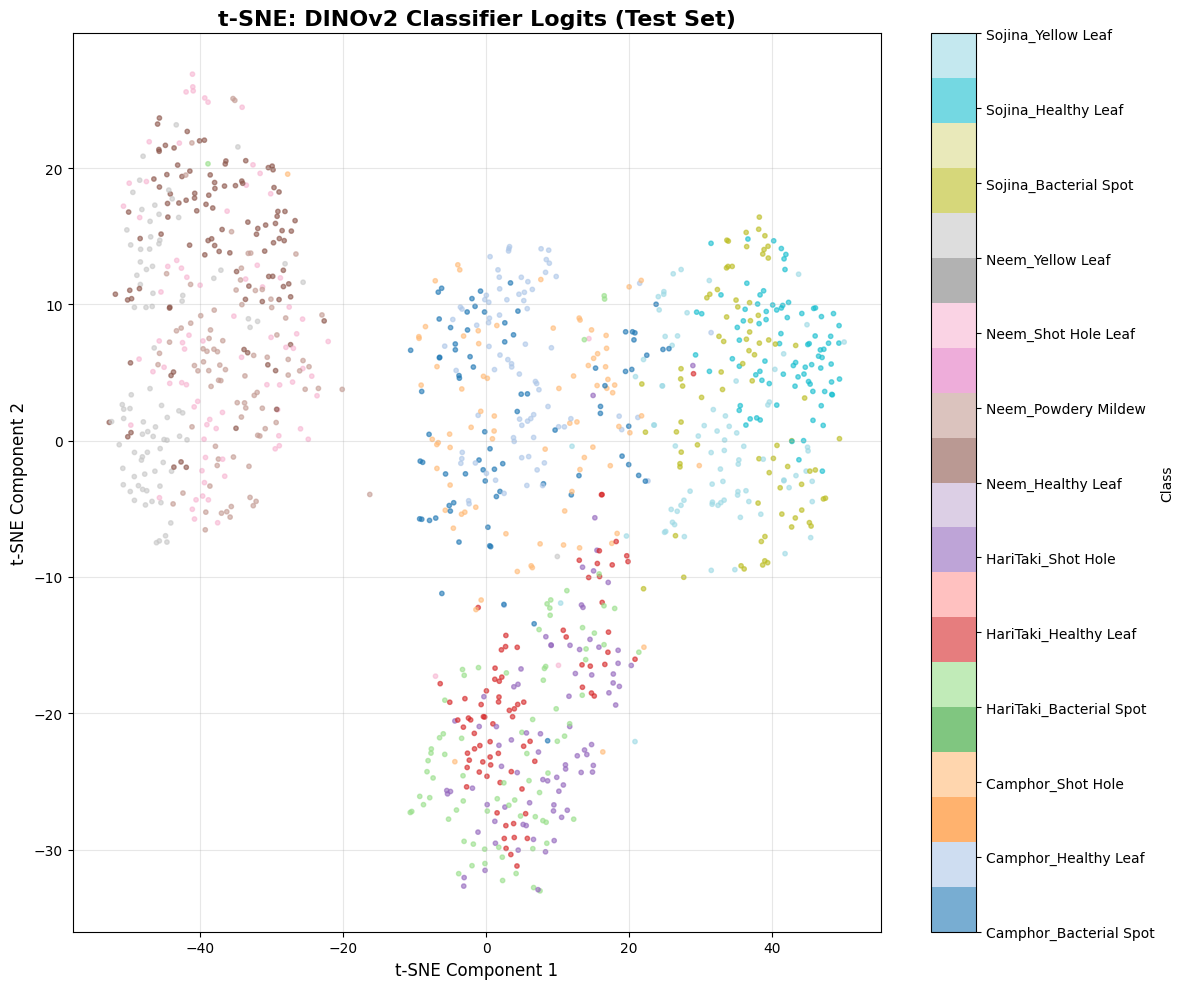


Extracting DINOv2 Backbone Features (768-dim)


Extracting embeddings: 100%|██████████| 34/34 [00:57<00:00,  1.70s/it]


Embeddings shape: (1086, 768)

Running t-SNE with perplexity=30...
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 1086 samples in 0.001s...
[t-SNE] Computed neighbors for 1086 samples in 0.212s...
[t-SNE] Computed conditional probabilities for sample 1000 / 1086
[t-SNE] Computed conditional probabilities for sample 1086 / 1086
[t-SNE] Mean sigma: 8.726267
[t-SNE] KL divergence after 250 iterations with early exaggeration: 55.886002
[t-SNE] KL divergence after 1000 iterations: 0.811849
Saved visualization to tsne_features_test.png


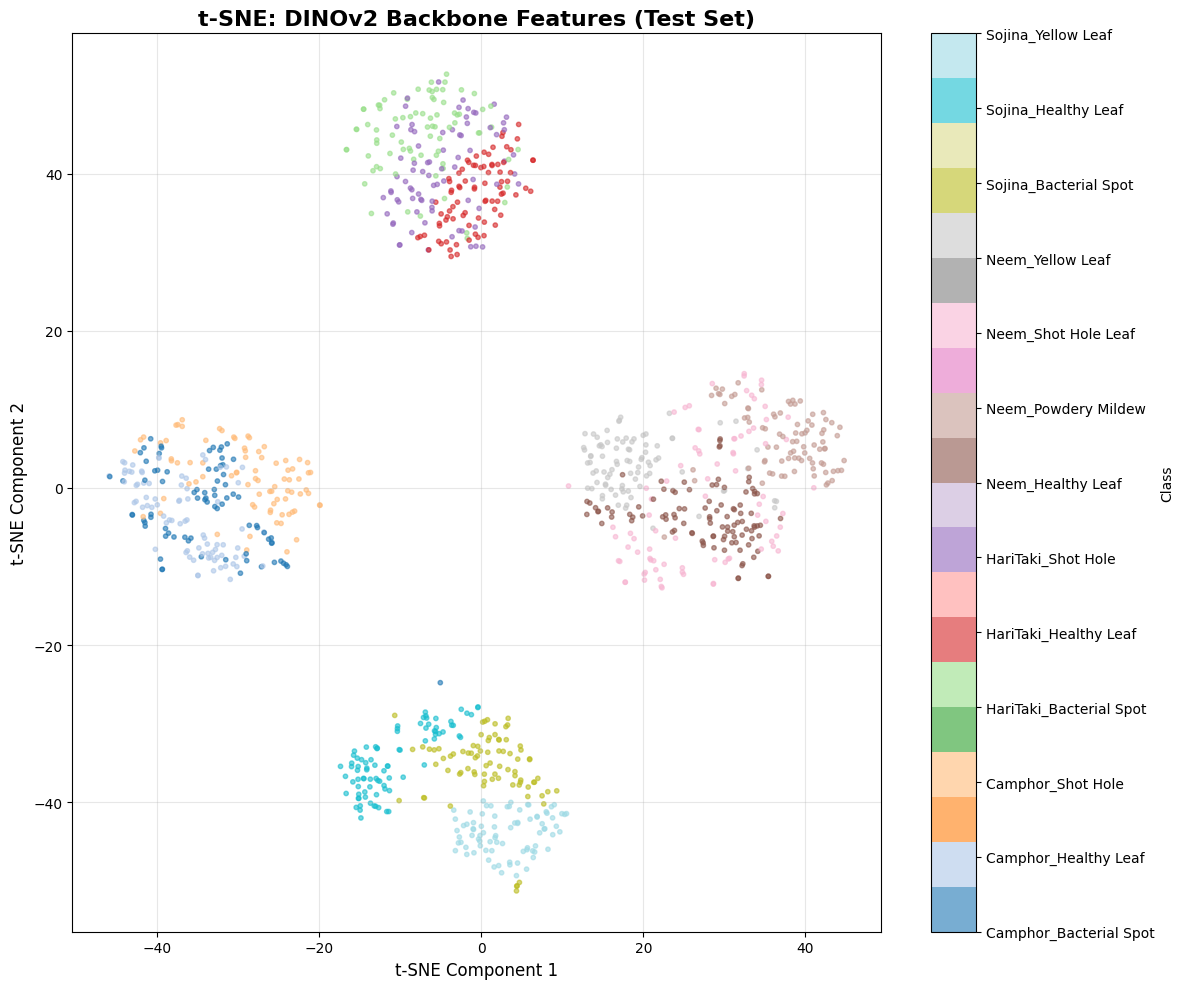


Comparing Different Perplexity Values for DINOv2 Backbone Features


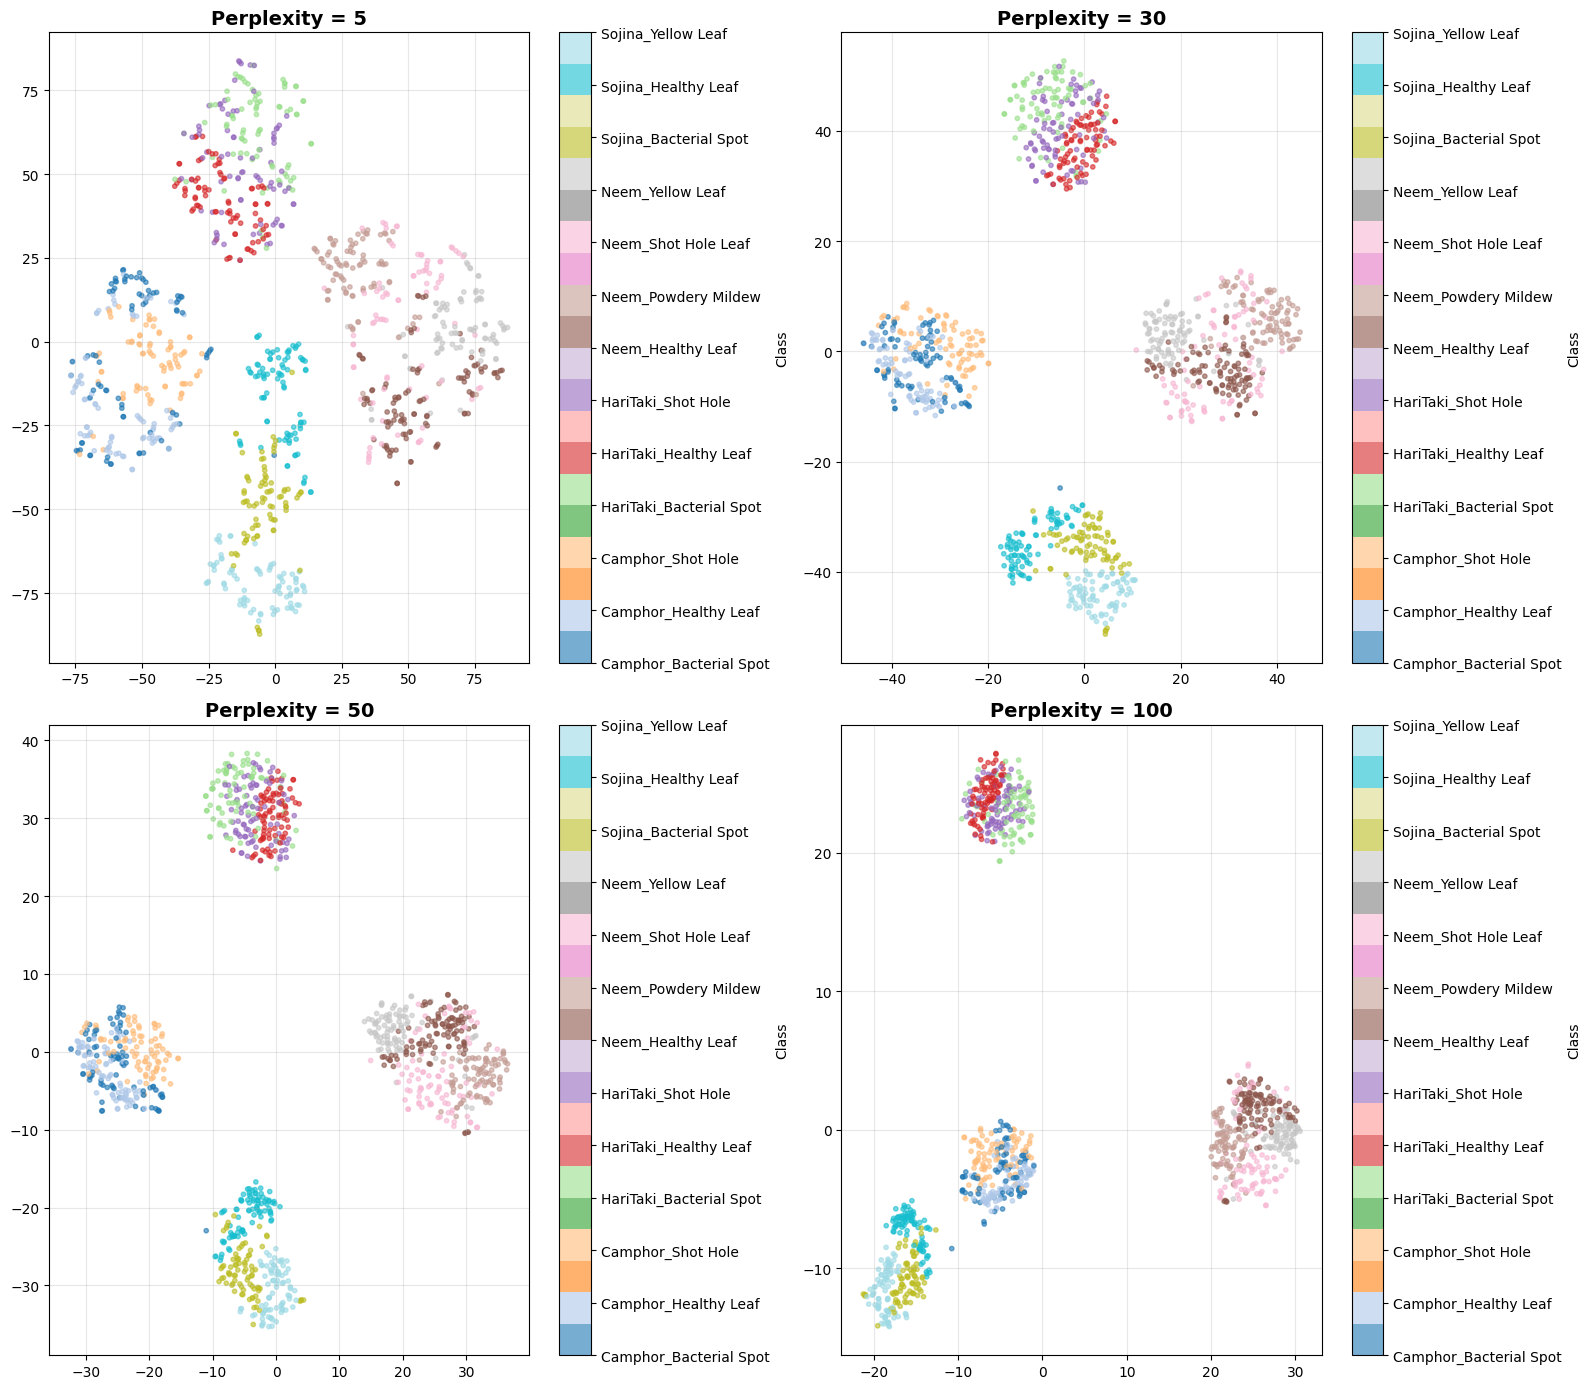


✅ t-SNE analysis complete!


In [15]:

# =====================================================
#  Extract Embeddings from Trained Model
# =====================================================
@torch.no_grad()
def extract_embeddings(model, loader, device, use_classifier_output=True):
    """
    Extract embeddings from the model.

    Args:
        model: Trained DINOv2Classifier model
        loader: DataLoader (train/val/test)
        device: torch device
        use_classifier_output: If True, use classification head output (logits, NUM_CLASSES-dim),
                               If False, use DINOv2 backbone features (768-dim for base model)

    Returns:
        embeddings: numpy array of shape (N, D)
        labels: numpy array of shape (N,)
    """
    model.eval()
    all_embeddings = []
    all_labels = []

    for images, labels in tqdm(loader, desc="Extracting embeddings"):
        images = images.to(device)

        if use_classifier_output:
            # Get classification head output (logits)
            embeddings = model(images)
        else:
            # Get DINOv2 backbone features
            embeddings = model.get_features(images)

        all_embeddings.append(embeddings.cpu().numpy())
        all_labels.append(labels.numpy())

    embeddings = np.vstack(all_embeddings)
    labels = np.concatenate(all_labels)

    return embeddings, labels


# =====================================================
#  t-SNE Visualization
# =====================================================
def visualize_tsne(embeddings, labels, title="t-SNE Visualization",
                   perplexity=30, n_iter=1000, random_state=42,
                   figsize=(12, 10), save_path=None, class_names=None):
    """
    Create t-SNE visualization of embeddings.

    Args:
        embeddings: numpy array of shape (N, D)
        labels: numpy array of shape (N,)
        title: Plot title
        perplexity: t-SNE perplexity parameter (5-50 recommended)
        n_iter: Number of iterations for optimization
        random_state: Random seed
        figsize: Figure size
        save_path: If provided, save figure to this path
        class_names: List of class names for colorbar labels
    """
    print(f"\nRunning t-SNE with perplexity={perplexity}...")

    # Run t-SNE
    tsne = TSNE(n_components=2, perplexity=perplexity, n_iter=n_iter,
                random_state=random_state, verbose=1)
    embeddings_2d = tsne.fit_transform(embeddings)

    # Create visualization
    plt.figure(figsize=figsize)
    scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1],
                         c=labels, cmap='tab20', alpha=0.6, s=10) # Changed cmap to tab20 for more distinct colors if NUM_CLASSES > 10

    # Add colorbar with class labels
    if class_names is not None:
        cbar = plt.colorbar(scatter, ticks=np.unique(labels), label='Class')
        cbar.set_ticklabels([class_names[i] for i in np.unique(labels)])
    else:
        plt.colorbar(scatter, label='Class')

    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('t-SNE Component 1', fontsize=12)
    plt.ylabel('t-SNE Component 2', fontsize=12)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved visualization to {save_path}")

    plt.show()

    return embeddings_2d


# =====================================================
#  Main t-SNE Execution
# =====================================================
def run_tsne_analysis(model, loader, device, dataset_name="Test", class_names=None):
    """
    Complete t-SNE analysis pipeline.

    Args:
        model: Trained DINOv2Classifier model
        loader: DataLoader
        device: torch device
        dataset_name: Name for plot titles and files
        class_names: List of class names for colorbar labels
    """
    # Using current model weights
    print("Using current DINOv2Classifier model weights.")

    # Extract embeddings from classification head (Logits, NUM_CLASSES-dim)
    print(f"\n{'='*60}")
    print(f"Extracting Classification Head Output (Logits, {NUM_CLASSES}-dim)") # Corrected this line
    print(f"{'='*60}")
    # Note: For t-SNE on classification outputs, it's often better to use Softmax probabilities or raw features.
    # Here, we'll use the raw logits.
    logits_embeddings, labels = extract_embeddings(
        model, loader, device, use_classifier_output=True
    )
    print(f"Embeddings shape: {logits_embeddings.shape}")
    print(f"Labels shape: {labels.shape}")

    visualize_tsne(
        logits_embeddings, labels,
        title=f"t-SNE: DINOv2 Classifier Logits ({dataset_name} Set)",
        save_path=f"tsne_logits_{dataset_name.lower()}.png",
        class_names=class_names # Pass class names for color bar
    )

    # Extract embeddings from DINOv2 backbone features (768-dim for base model)
    print(f"\n{'='*60}")
    print(f"Extracting DINOv2 Backbone Features ({model.feature_extractor.embed_dim}-dim)") # Corrected this line
    print(f"{'='*60}")
    feature_embeddings, labels = extract_embeddings(
        model, loader, device, use_classifier_output=False
    )
    print(f"Embeddings shape: {feature_embeddings.shape}")

    visualize_tsne(
        feature_embeddings, labels,
        title=f"t-SNE: DINOv2 Backbone Features ({dataset_name} Set)",
        save_path=f"tsne_features_{dataset_name.lower()}.png",
        class_names=class_names # Pass class names for color bar
    )

    return logits_embeddings, feature_embeddings, labels


# =====================================================
#  DATA LOADER SETUP FOR T-SNE AND DOWNSTREAM TASKS
# =====================================================

# Create transformations for DINOv2
train_transform = get_dinov2_transforms(is_training=True, img_size=IMG_SIZE)
test_val_transform = get_dinov2_transforms(is_training=False, img_size=IMG_SIZE)

# Function to prepare datasets and dataloaders
def prepare_data_loaders(dataframe, transform, shuffle=False):
    image_paths = dataframe['path'].tolist()
    # Convert string labels to integer IDs using the global class_to_idx mapping
    labels = [class_to_idx[label] for label in dataframe['label'].tolist()]
    dataset = ImageDataset(image_paths, labels, transform)
    loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=shuffle, num_workers=2)
    return loader

# Create DataLoaders
train_loader = prepare_data_loaders(train, train_transform, shuffle=True)
val_loader = prepare_data_loaders(val, test_val_transform, shuffle=False)
test_loader = prepare_data_loaders(test, test_val_transform, shuffle=False)

print(f"Train DataLoader created with {len(train_loader.dataset)} images.")
print(f"Validation DataLoader created with {len(val_loader.dataset)} images.")
print(f"Test DataLoader created with {len(test_loader.dataset)} images.")


# =====================================================
#  Usage Example
# =====================================================
if __name__ == "__main__":
    # Get class names from idx_to_class for visualization
    sorted_class_names = [idx_to_class[i] for i in sorted(idx_to_class.keys())]

    # Run t-SNE on test set
    logits_emb, feature_emb, test_labels = run_tsne_analysis(
        m_model, test_loader, DEVICE, dataset_name="Test", class_names=sorted_class_names
    )

    # Optional: Run on validation set
    # logits_emb_val, feature_emb_val, val_labels = run_tsne_analysis(
    #     m_model, val_loader, DEVICE, dataset_name="Validation", class_names=sorted_class_names
    # )

    # Optional: Compare different perplexity values
    print("\n" + "="*60)
    print("Comparing Different Perplexity Values for DINOv2 Backbone Features")
    print("="*60)

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))
    perplexities = [5, 30, 50, 100]

    for idx, perp in enumerate(perplexities):
        ax = axes[idx // 2, idx % 2]
        tsne = TSNE(n_components=2, perplexity=perp, random_state=42)
        # Use feature_emb (DINOv2 backbone features) for perplexity comparison
        emb_2d = tsne.fit_transform(feature_emb)

        scatter = ax.scatter(emb_2d[:, 0], emb_2d[:, 1],
                           c=test_labels, cmap='tab20', alpha=0.6, s=10) # Use tab20
        ax.set_title(f'Perplexity = {perp}', fontsize=14, fontweight='bold')
        ax.grid(True, alpha=0.3)

        # Add colorbar with class labels for perplexity comparison plots
        if sorted_class_names is not None:
            cbar = plt.colorbar(scatter, ax=ax, ticks=np.unique(test_labels), label='Class')
            cbar.set_ticklabels([sorted_class_names[i] for i in np.unique(test_labels)])
        else:
            plt.colorbar(scatter, ax=ax, label='Class')


    plt.tight_layout()
    plt.savefig('tsne_perplexity_comparison_dinov2_features.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\n\u2705 t-SNE analysis complete!")


In [16]:
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)

            feats = model.get_features(images)   # (batch, feature_dim)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels


In [17]:
# -----------------------------
# 1‶ Feature Extraction
# -----------------------------
def extract_features(model, dataloader, device):
    model.eval()
    all_features = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Extracting features"):
            images = images.to(device)
            # Use model.get_features if it's the DINOv2Classifier
            # If model were MoCov3, its extract_features method should be used.
            # Here, we intend to use the DINOv2Classifier for feature extraction.
            feats = model.get_features(images)  # (batch, feature_dim)
            all_features.append(feats.cpu().numpy())
            all_labels.append(labels.numpy())

    all_features = np.concatenate(all_features, axis=0)
    all_labels = np.concatenate(all_labels, axis=0)

    return all_features, all_labels

# Extract train/validation features using m_model (DINOv2Classifier)
train_X, train_y = extract_features(m_model, train_loader, DEVICE)
val_X, val_y = extract_features(m_model, val_loader, DEVICE)

# -----------------------------
# 2‶ Standardize Features
# -----------------------------
scaler = StandardScaler()
train_X = scaler.fit_transform(train_X)
val_X = scaler.transform(val_X)

# -----------------------------
# 3‶ Dimensionality Reduction (Optional but recommended)
# -----------------------------
pca = PCA(n_components=512)  # reduce to 512 features
train_X = pca.fit_transform(train_X)
val_X = pca.transform(val_X)

# -----------------------------
# 4‶ Train MLP Classifier
# -----------------------------
mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=1000,
    random_state=42,
    verbose=True
)

mlp.fit(train_X, train_y)

# -----------------------------
# 5‶ Evaluate Accuracy
# -----------------------------
preds = mlp.predict(val_X)
acc = accuracy_score(val_y, preds)
print(f"\n❌ Optimized MLP Accuracy: {acc * 100:.2f}%")


Extracting features: 100%|██████████| 31/31 [00:52<00:00,  1.69s/it]


Iteration 1, loss = 1.15865133
Iteration 2, loss = 0.29372279
Iteration 3, loss = 0.16495327
Iteration 4, loss = 0.11150419
Iteration 5, loss = 0.08218290
Iteration 6, loss = 0.06327734
Iteration 7, loss = 0.05054201
Iteration 8, loss = 0.04048041
Iteration 9, loss = 0.03374190
Iteration 10, loss = 0.02732118
Iteration 11, loss = 0.02242832
Iteration 12, loss = 0.01893804
Iteration 13, loss = 0.01622704
Iteration 14, loss = 0.01370413
Iteration 15, loss = 0.01159838
Iteration 16, loss = 0.00988330
Iteration 17, loss = 0.00869046
Iteration 18, loss = 0.00748343
Iteration 19, loss = 0.00667928
Iteration 20, loss = 0.00584212
Iteration 21, loss = 0.00519111
Iteration 22, loss = 0.00475895
Iteration 23, loss = 0.00426619
Iteration 24, loss = 0.00386395
Iteration 25, loss = 0.00345383
Iteration 26, loss = 0.00323448
Iteration 27, loss = 0.00292153
Iteration 28, loss = 0.00266160
Iteration 29, loss = 0.00247864
Iteration 30, loss = 0.00231849
Iteration 31, loss = 0.00212010
Iteration 32, los

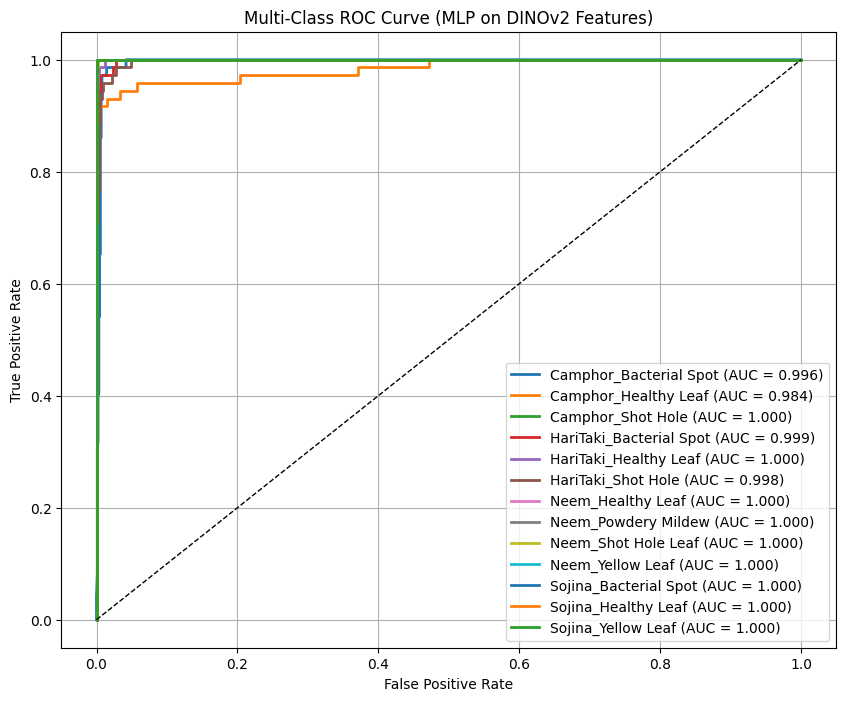

In [18]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# ===============================================
# 🔥 1️⃣ Get Probability Predictions from the MLP
# ===============================================
probs = mlp.predict_proba(val_X)      # shape = (N, NUM_CLASSES)
labels = val_y                        # true labels


# ===============================================
# 🔥 2️⃣ Binarize labels for Multi-Class ROC
# ===============================================
y_bin = label_binarize(labels, classes=list(range(NUM_CLASSES)))


# ===============================================
# 🔥 3️⃣ Plot ROC Curve for Each Class
# ===============================================
plt.figure(figsize=(10, 8))

class_names = list(class_to_idx.keys())  # optional, for prettier legends

for i in range(NUM_CLASSES):
    fpr, tpr, _ = roc_curve(y_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)

    if class_names:
        label = f"{class_names[i]} (AUC = {roc_auc:.3f})"
    else:
        label = f"Class {i} (AUC = {roc_auc:.3f})"

    plt.plot(fpr, tpr, lw=2, label=label)


# ===============================================
# 🔥 4️⃣ Plot Formatting
# ===============================================
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multi-Class ROC Curve (MLP on DINOv2 Features)")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()



✅ Overall Accuracy: 97.24%

📌 Per-Class Accuracy:
                         Accuracy (%)
Camphor_Bacterial Spot          97.22
Camphor_Healthy Leaf            86.11
Camphor_Shot Hole               98.61
HariTaki_Bacterial Spot         93.06
HariTaki_Healthy Leaf           98.65
HariTaki_Shot Hole              93.06
Neem_Healthy Leaf               98.91
Neem_Powdery Mildew            100.00
Neem_Shot Hole Leaf             97.33
Neem_Yellow Leaf               100.00
Sojina_Bacterial Spot          100.00
Sojina_Healthy Leaf            100.00
Sojina_Yellow Leaf             100.00

📄 Classification Report:
                         precision  recall  f1-score  support
Camphor_Bacterial Spot       0.864   0.972     0.915   72.000
Camphor_Healthy Leaf         0.969   0.861     0.912   72.000
Camphor_Shot Hole            1.000   0.986     0.993   72.000
HariTaki_Bacterial Spot      0.971   0.931     0.950   72.000
HariTaki_Healthy Leaf        0.961   0.986     0.973   74.000
HariTaki_Shot Hole 

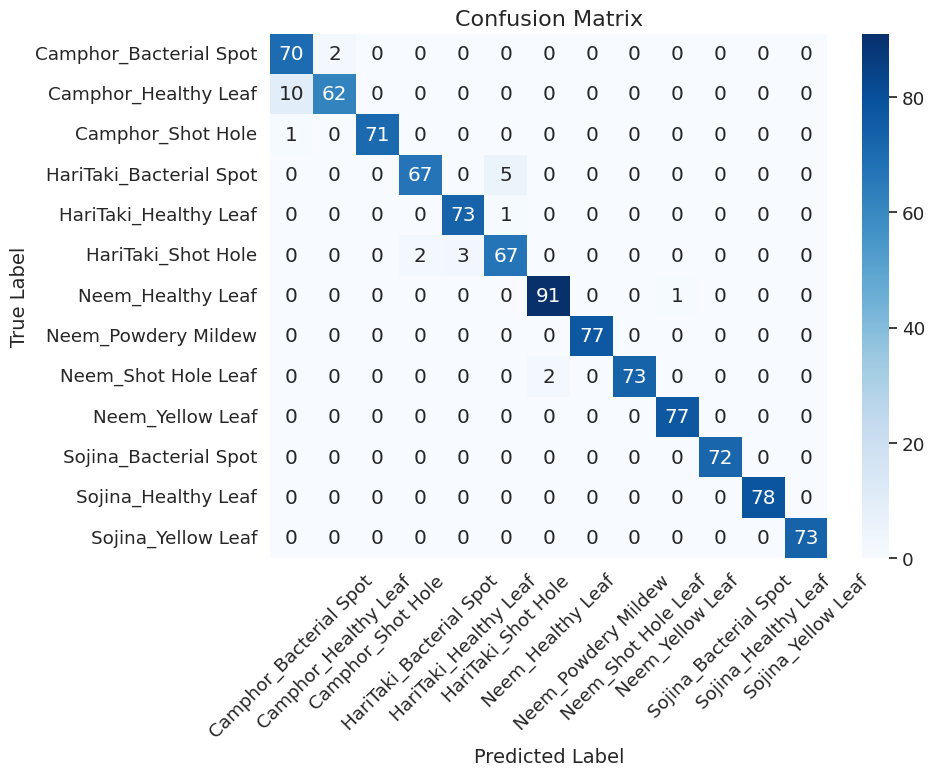

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# ------------------------------
# 1️⃣ Predictions
# ------------------------------
preds = mlp.predict(val_X)

# ------------------------------
# 2️⃣ Overall Accuracy
# ------------------------------
overall_acc = accuracy_score(val_y, preds)
print(f"\n✅ Overall Accuracy: {overall_acc * 100:.2f}%")

# ------------------------------
# 3️⃣ Per-Class Accuracy
# ------------------------------
per_class_acc = {}
for c in range(NUM_CLASSES):
    idx = np.where(val_y == c)[0]  # indices of class c
    class_acc = accuracy_score(val_y[idx], preds[idx])
    class_name = list(class_to_idx.keys())[c]
    per_class_acc[class_name] = class_acc * 100

# Display per-class accuracy in a professional table
df_acc = pd.DataFrame.from_dict(per_class_acc, orient='index', columns=['Accuracy (%)'])
df_acc = df_acc.sort_index()
print("\n📌 Per-Class Accuracy:")
print(df_acc.to_string(float_format='%.2f'))

# ------------------------------
# 4️⃣ Classification Report (Precision, Recall, F1)
# ------------------------------
print("\n📄 Classification Report:")
report = classification_report(
    val_y, preds,
    target_names=list(class_to_idx.keys()),
    digits=3,
    output_dict=True
)
df_report = pd.DataFrame(report).T
print(df_report.round(3))

# Macro averages
macro_precision = precision_score(val_y, preds, average='macro')
macro_recall = recall_score(val_y, preds, average='macro')
macro_f1 = f1_score(val_y, preds, average='macro')

print(f"\n🔹 Macro Precision: {macro_precision:.3f}")
print(f"🔹 Macro Recall:    {macro_recall:.3f}")
print(f"🔹 Macro F1-score:  {macro_f1:.3f}")

# ------------------------------
# 5️⃣ Confusion Matrix Visualization
# ------------------------------
cm = confusion_matrix(val_y, preds)
plt.figure(figsize=(10, 8))
sns.set(font_scale=1.2)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=list(class_to_idx.keys()),
    yticklabels=list(class_to_idx.keys()),
    cbar=True
)
plt.xlabel('Predicted Label', fontsize=14)
plt.ylabel('True Label', fontsize=14)
plt.title('Confusion Matrix', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Iteration 1, loss = 1.15865133
Iteration 2, loss = 0.29372279
Iteration 3, loss = 0.16495327
Iteration 4, loss = 0.11150419
Iteration 5, loss = 0.08218290
Iteration 6, loss = 0.06327734
Iteration 7, loss = 0.05054201
Iteration 8, loss = 0.04048041
Iteration 9, loss = 0.03374190
Iteration 10, loss = 0.02732118
Iteration 11, loss = 0.02242832
Iteration 12, loss = 0.01893804
Iteration 13, loss = 0.01622704
Iteration 14, loss = 0.01370413
Iteration 15, loss = 0.01159838
Iteration 16, loss = 0.00988330
Iteration 17, loss = 0.00869046
Iteration 18, loss = 0.00748343
Iteration 19, loss = 0.00667928
Iteration 20, loss = 0.00584212
Iteration 21, loss = 0.00519111
Iteration 22, loss = 0.00475895
Iteration 23, loss = 0.00426619
Iteration 24, loss = 0.00386395
Iteration 25, loss = 0.00345383
Iteration 26, loss = 0.00323448
Iteration 27, loss = 0.00292153
Iteration 28, loss = 0.00266160
Iteration 29, loss = 0.00247864
Iteration 30, loss = 0.00231849
Iteration 31, loss = 0.00212010
Iteration 32, los

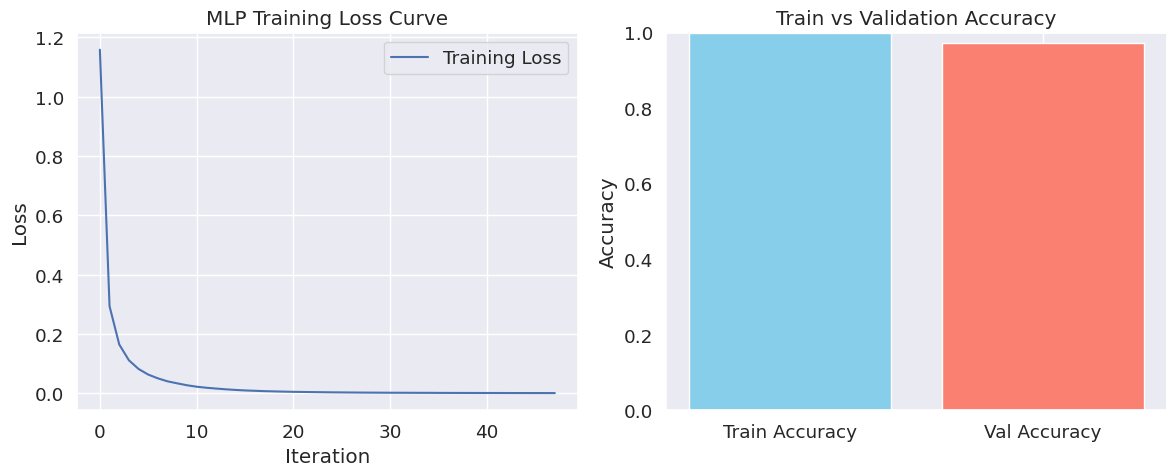

In [20]:
import time
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# ------------------------------
# 1️⃣ Track Train/Validation Loss & Accuracy
# ------------------------------

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# ------------------------------
# 2️⃣ Timing
# ------------------------------
start_time = time.time()

# MLP training (with timing)
mlp = MLPClassifier(
    hidden_layer_sizes=(1024, 512, 256),
    activation='relu',
    solver='adam',
    learning_rate_init=0.0001,
    max_iter=1000,
    random_state=42,
    verbose=True
)

mlp_start = time.time()
mlp.fit(train_X, train_y)
mlp_end = time.time()

train_time = mlp_end - mlp_start

# ------------------------------
# 3️⃣ Evaluate on Train & Validation for Learning Curve
# ------------------------------
# Training set
train_preds = mlp.predict(train_X)
train_acc = accuracy_score(train_y, train_preds)

# Validation set
val_preds = mlp.predict(val_X)
val_acc = accuracy_score(val_y, val_preds)

# Save metrics
train_accuracies.append(train_acc)
val_accuracies.append(val_acc)

# If you want loss per epoch, sklearn MLP doesn't directly give it,
# but you can access `mlp.loss_curve_`
train_losses = mlp.loss_curve_
val_losses = [None]*len(train_losses)  # sklearn does not provide validation loss per epoch

end_time = time.time()
total_time = end_time - start_time

print(f"\n⏱ Training Time: {train_time:.2f} sec")
print(f"⏱ Total Execution Time (including eval): {total_time:.2f} sec")

# ------------------------------
# 4️⃣ Plot Learning Curves
# ------------------------------
plt.figure(figsize=(12, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Training Loss")
plt.title("MLP Training Loss Curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()

# Accuracy curve
plt.subplot(1, 2, 2)
plt.bar(['Train Accuracy', 'Val Accuracy'], [train_acc, val_acc], color=['skyblue', 'salmon'])
plt.ylim(0, 1)
plt.title("Train vs Validation Accuracy")
plt.ylabel("Accuracy")
plt.grid(axis='y')

plt.tight_layout()
plt.show()


In [21]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# ------------------------------
# 1️⃣ Define k values
# ------------------------------
k_values = [1, 5, 20]

# ------------------------------
# 2️⃣ Evaluate k-NN for each k
# ------------------------------
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k, metric='cosine')  # cosine distance works well for embeddings
    knn.fit(train_X, train_y)

    # Predict on validation set
    val_preds = knn.predict(val_X)
    acc = accuracy_score(val_y, val_preds)

    print(f"🔹 k = {k}: Validation Accuracy = {acc * 100:.2f}%")


🔹 k = 1: Validation Accuracy = 87.32%
🔹 k = 5: Validation Accuracy = 87.83%
🔹 k = 20: Validation Accuracy = 86.81%


✅ 1% labeled data (87 samples): Accuracy = 70.14%
✅ 5% labeled data (439 samples): Accuracy = 87.32%
✅ 10% labeled data (879 samples): Accuracy = 90.80%
✅ 25% labeled data (2198 samples): Accuracy = 93.97%
✅ 50% labeled data (4397 samples): Accuracy = 95.09%


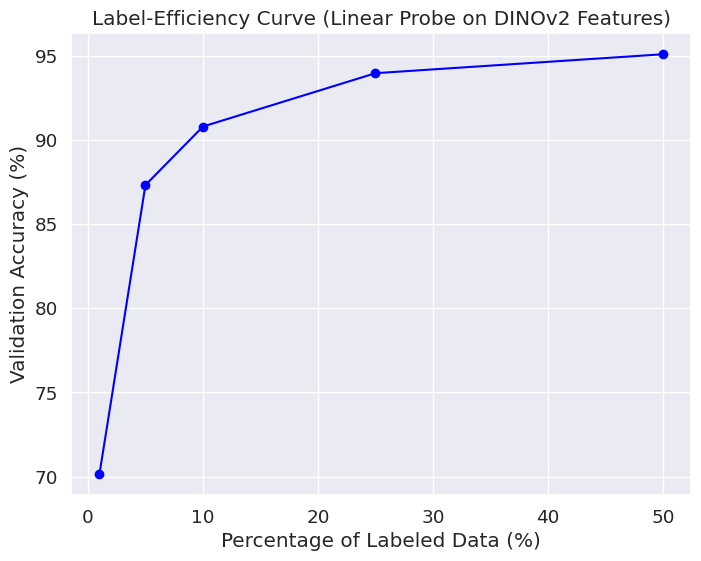

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# ------------------------------
# 1️⃣ Define labeled fractions
# ------------------------------
fractions = [0.01, 0.05, 0.10, 0.25, 0.50]  # 1%, 5%, 10%, 25%, 50%
n_train = train_X.shape[0]

linear_probe_accuracies = []

# ------------------------------
# 2️⃣ Train linear probes with subsets
# ------------------------------
for frac in fractions:
    n_samples = max(1, int(n_train * frac))  # at least 1 sample
    np.random.seed(42)
    indices = np.random.choice(n_train, n_samples, replace=False)

    X_subset = train_X[indices]
    y_subset = train_y[indices]

    # Linear classifier (logistic regression)
    clf = LogisticRegression(
        multi_class='multinomial',
        solver='lbfgs',
        max_iter=1000,
        random_state=42
    )

    clf.fit(X_subset, y_subset)

    # Evaluate on validation set
    val_preds = clf.predict(val_X)
    acc = accuracy_score(val_y, val_preds)

    linear_probe_accuracies.append(acc)
    print(f"✅ {frac*100:.0f}% labeled data ({n_samples} samples): Accuracy = {acc*100:.2f}%")

# ------------------------------
# 3️⃣ Plot Label-Efficiency Curve
# ------------------------------
plt.figure(figsize=(8,6))
plt.plot([f*100 for f in fractions], [a*100 for a in linear_probe_accuracies], marker='o', color='blue')
plt.xlabel("Percentage of Labeled Data (%)")
plt.ylabel("Validation Accuracy (%)")
plt.title("Label-Efficiency Curve (Linear Probe on DINOv2 Features)")
plt.grid(True)
plt.show()
